# Simulations used in lecturenote

This file gives the output for the simulation used in the lecturenote. First we import functions and libraries:

In [156]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import importlib
sys.path.append(os.path.abspath(".."))

# Import functions
from functions import simulation_master
from functions import bubble_simulation

# Reload functions
importlib.reload(simulation_master)
importlib.reload(bubble_simulation)

<module 'functions.bubble_simulation' from '/Users/emilrand/Desktop/Uni/Bachelor/6. semester/BA_Emil/BA_repo/emil/../functions/bubble_simulation.py'>

Now we plot a simple AR(1) with a unit root / random walk:

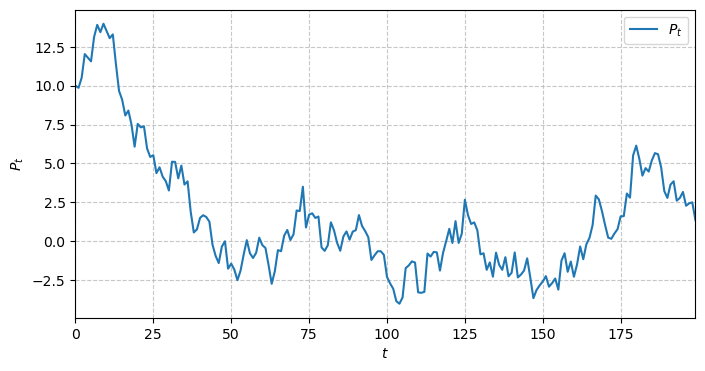

In [37]:
# Standard random walk: P_t = P_{t-1} + eps_t
T = 200
P_rw = simulation_master.simulate_ar1_price(
    T=T,
    rho=1,
    sigma=1,
    mu=0.0,
    P0=10.0,
    seed=42,
)

plt.figure(figsize=(8, 4))
plt.plot(P_rw.index, P_rw.values, label="$P_t$")
plt.xlabel("$t$")
plt.ylabel("$P_t$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.margins(x=0)
plt.show()

# save P_rw as csv to data folder
P_rw.to_csv("../data/P_rw.csv", index=False)

Taking the above series from P_rw.csv, and test it with the exuber package yields following results, which means we do not reject $H_0$, as we would expect, since this is indeed a random walk $\rho = 1$. 

And the BSADF looks like this

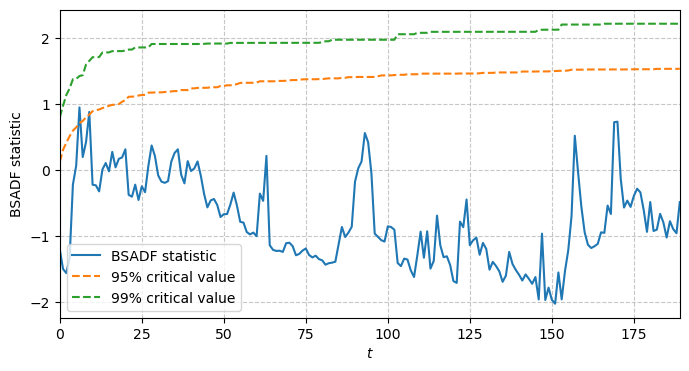

In [78]:
# Load BSADF statistic and critical values for P_rw
P_rw_bsadf_stat = pd.read_csv("../data/bsadf/P_rw_bsadf_stat.csv")   # column: "bsadf"
P_rw_bsadf_cv   = pd.read_csv("../data/bsadf/P_rw_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

t = np.arange(len(P_rw_bsadf_stat))  # time index

plt.figure(figsize=(8, 4))
plt.plot(t, P_rw_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_rw_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_rw_bsadf_cv["99%"], "--", label="99% critical value")

plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.show()

Now we introduce a single bubble to the series, so $P_t$ will look like this

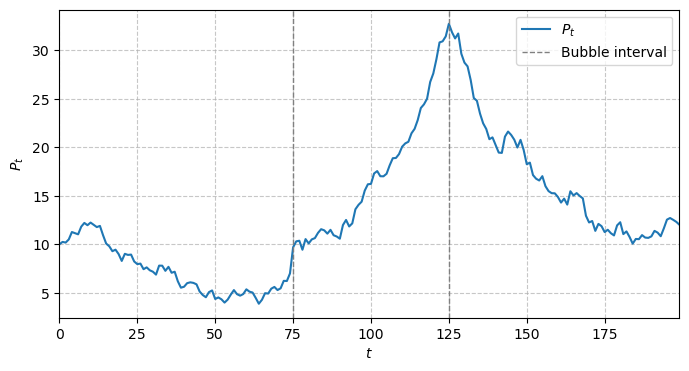

In [95]:
T = 200
Pf, B, P = simulation_master.simulate_price_with_bubbles(
    T=T,
    P0=10.0,
    rho=1.0,              # random walk fundamental
    include_bubble=True,
    R=0.04,
    sigma_b=0.5,
    bubble_decay=0.95,
    t_start1=75,          # first bubble interval
    t_end1=125,
    B0_1=4.0,
    seed=42,
)

plt.figure(figsize=(8, 4))
plt.plot(P, label=r"$P_t$")
# plt.plot(Pf, label=r"$P_t^f$", linestyle="--")
# plt.plot(B, label=r"$B_t$")
plt.xlabel("$t$")
plt.axvline(75, color="grey", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(125, color="grey", linestyle="--", linewidth=1)
plt.ylabel("$P_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.legend()
plt.show()

# Save price series as csv to data folder
P.to_csv("../data/P_rw_bubble.csv", index=False)

The results are given below. We do not reject with ADF on whole sample. But we reject with SADF and GSADF.

The BSADF results are displayed below, where it is also clear.

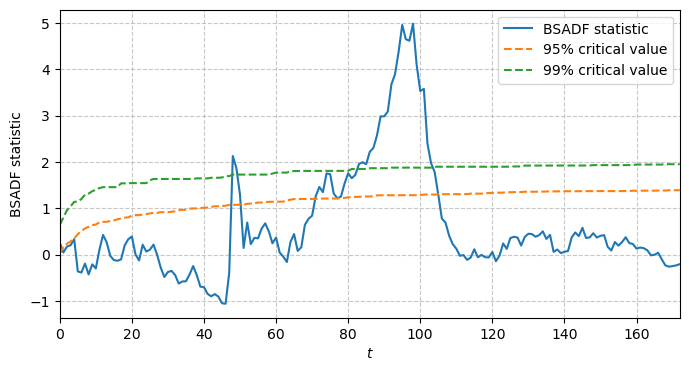

In [79]:
# Load BSADF statistic and critical values for P_rw
P_rw_bubble_bsadf_stat = pd.read_csv("../data/bsadf/P_rw_bubble_bsadf_stat.csv")   # column: "bsadf"
P_rw_bubble_bsadf_cv   = pd.read_csv("../data/bsadf/P_rw_bubble_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

t = np.arange(len(P_rw_bubble_bsadf_stat))  # time index

plt.figure(figsize=(8, 4))
plt.plot(t, P_rw_bubble_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_rw_bubble_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_rw_bubble_bsadf_cv["99%"], "--", label="99% critical value")

plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.show()

And with correct window size starting time (adjusted for the window size starting at 27)

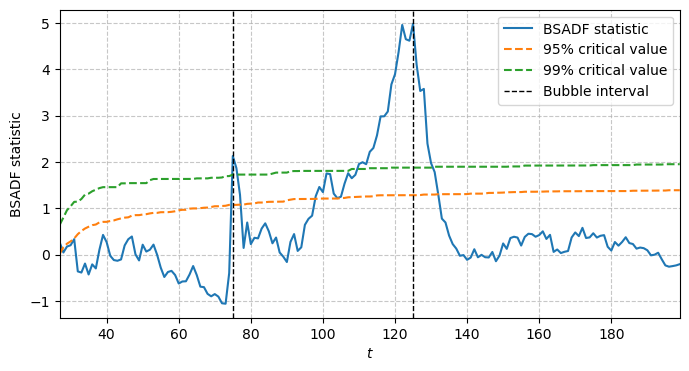

In [93]:
# Load BSADF statistic and critical values for P_rw
P_rw_bubble_bsadf_stat = pd.read_csv("../data/bsadf/P_rw_bubble_bsadf_stat.csv")   # column: "bsadf"
P_rw_bubble_bsadf_cv   = pd.read_csv("../data/bsadf/P_rw_bubble_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

# Load original price series to get T
P_rw_bubble = pd.read_csv("../data/P_rw_bubble.csv")
T = len(P_rw_bubble)

n_bsadf = len(P_rw_bubble_bsadf_stat)
offset = T - n_bsadf            # number of periods at the start with no BSADF
t = np.arange(offset, offset + n_bsadf)   # length matches n_bsadf

plt.figure(figsize=(8, 4))
plt.plot(t, P_rw_bubble_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_rw_bubble_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_rw_bubble_bsadf_cv["99%"], "--", label="99% critical value")
plt.axvline(75, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(125, color="black", linestyle="--", linewidth=1)
plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.show()

Now we do the same on simulated data where $\rho<1$ on both sides of the bubble to show the test is still working with a bubble. The stationary AR(1) with e.g. $\rho = 0.8$ looks like this:

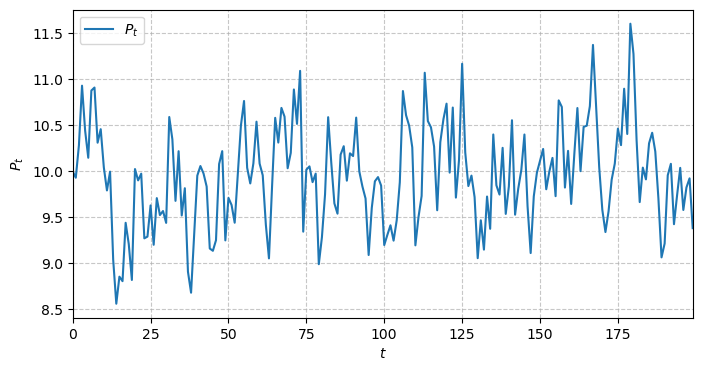

In [105]:
# Standard random walk: P_t = P_{t-1} + eps_t
T = 200
P_stationary = simulation_master.simulate_ar1_price(
    T=T,
    rho=0.6,
    sigma=0.5,
    mu=4.0,
    P0=10.0,
    seed=42,
)

plt.figure(figsize=(8, 4))
plt.plot(P_stationary.index, P_stationary.values, label="$P_t$")
plt.xlabel("$t$")
plt.ylabel("$P_t$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.margins(x=0)
plt.show()

And with a bubble

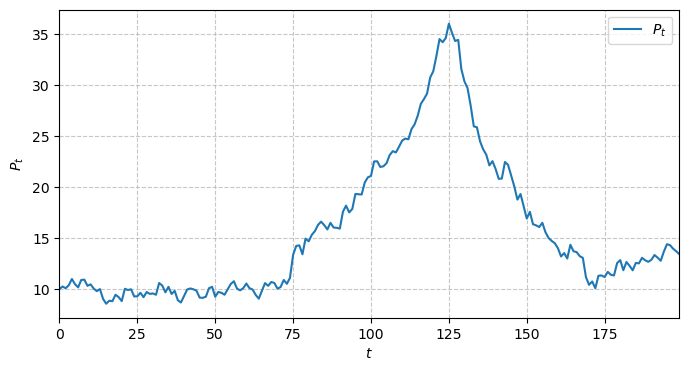

In [109]:
T = 200
Pf, B, P = simulation_master.simulate_price_with_bubbles(
    T=T,
    P0=10.0,
    rho=0.6,              # random walk fundamental
    include_bubble=True,
    R=0.04,
    sigma_b=0.5,
    mu_f=4.0,
    bubble_decay=0.95,
    t_start1=75,          # first bubble interval
    t_end1=125,
    B0_1=4.0,
    seed=42,
)

plt.figure(figsize=(8, 4))
plt.plot(P, label=r"$P_t$")
# plt.plot(Pf, label=r"$P_t^f$", linestyle="--")
# plt.plot(B, label=r"$B_t$")
plt.xlabel("$t$")
plt.ylabel("$P_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.legend()
plt.show()

# Save price series as csv to data folder
P.to_csv("../data/P_stationary_bubble.csv", index=False)

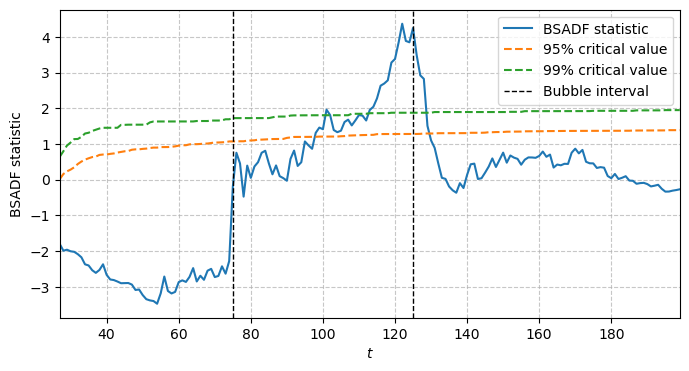

In [113]:
# Load BSADF statistic and critical values for P_rw
P_stationary_bubble_bsadf_stat = pd.read_csv("../data/bsadf/P_stationary_bubble_bsadf_stat.csv")   # column: "bsadf"
P_stationary_bubble_bsadf_cv   = pd.read_csv("../data/bsadf/P_stationary_bubble_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

# Load original price series to get T
P_stationary_bubble = pd.read_csv("../data/P_stationary_bubble.csv")
T = len(P_stationary_bubble)

n_bsadf = len(P_stationary_bubble_bsadf_stat)
offset = T - n_bsadf            # number of periods at the start with no BSADF
t = np.arange(offset, offset + n_bsadf)   # length matches n_bsadf

plt.figure(figsize=(8, 4))
plt.plot(t, P_stationary_bubble_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_stationary_bubble_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_stationary_bubble_bsadf_cv["99%"], "--", label="99% critical value")
plt.axvline(75, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(125, color="black", linestyle="--", linewidth=1)
plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.show()

Now we want to show 2 bubbles and different values of $\rho$ over the samplem to show the procedure is still detecting explosive bubbles, and including a trend to mimic steady, normal growth. 

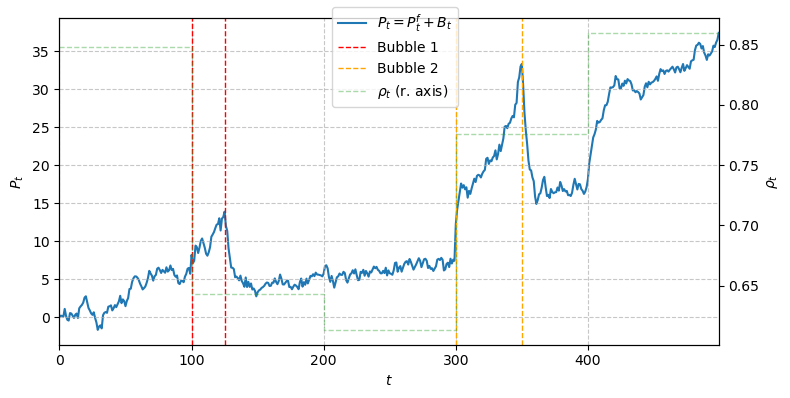

In [206]:
T = 500
Pf_tv, B_tv, P_tv = simulation_master.simulate_price_with_bubbles(
    T=T,
    random_rho=True,
    rho_min=0.5,
    rho_max=1.0,
    rho_block_size=100,
    trend_f=0.01,
    include_bubble=True,
    t_start1=100,
    t_end1=125,
    B0_1=4.0,
    t_start2=300,
    t_end2=350,
    B0_2=4.0,
    bubble_decay=0.8,
    seed=123,
)

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left axis: price
ax1.plot(P_tv.index, P_tv.values, label=r"$P_t = P_t^f + B_t$", color="tab:blue", zorder=1)
ax1.set_xlabel("$t$")
ax1.set_ylabel(r"$P_t$")
ax1.tick_params(axis="y")
ax1.axvline(100, color="red", linestyle="--", label="Bubble 1", linewidth=1)
ax1.axvline(125, color="red", linestyle="--", linewidth=1)
ax1.axvline(300, color="orange", linestyle="--", label="Bubble 2", linewidth=1)
ax1.axvline(350, color="orange", linestyle="--", linewidth=1) 
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.margins(x=0)

# Right axis: rho_t
ax2 = ax1.twinx()
ax2.step(rho_tv.index, rho_tv.values, where="post", color="tab:green", label=r"$\rho_t$ (r. axis)", zorder=0, linestyle="--", alpha=0.4, linewidth=1)
ax2.set_ylabel(r"$\rho_t$")
ax2.tick_params(axis="y")
ax2.set_zorder(0)
fig.legend(loc="upper center")
fig.tight_layout()
plt.show()

# download as csv
P_tv.to_csv("../data/P_tv.csv", index=False)

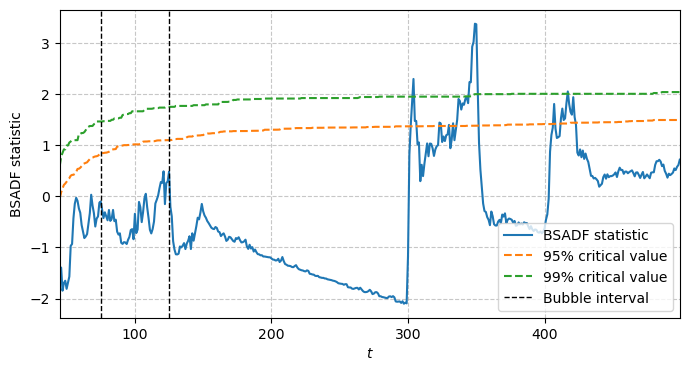

In [209]:
# Load BSADF statistic and critical values for P_rw
P_tv_bsadf_stat = pd.read_csv("../data/bsadf/P_tv_bsadf_stat.csv")   # column: "bsadf"
P_tv_bsadf_cv   = pd.read_csv("../data/bsadf/P_tv_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

# Load original price series to get T
P_tv = pd.read_csv("../data/P_tv.csv")
T = len(P_tv)

n_bsadf = len(P_tv_bsadf_stat)
offset = T - n_bsadf            # number of periods at the start with no BSADF
t = np.arange(offset, offset + n_bsadf)   # length matches n_bsadf

plt.figure(figsize=(8, 4))
plt.plot(t, P_tv_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_tv_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_tv_bsadf_cv["99%"], "--", label="99% critical value")
plt.axvline(75, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(125, color="black", linestyle="--", linewidth=1)
plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.show()